cuda:0


Training:   0%|          | 0/1250 [00:00<?, ?it/s]

{'train': [{'loss': 2.9752814769744873, 'step': 1}, {'loss': 2.3599953651428223, 'step': 2}, {'loss': 1.772403597831726, 'step': 3}, {'loss': 1.1950719356536865, 'step': 4}, {'loss': 0.6779897809028625, 'step': 5}, {'loss': 0.6280173063278198, 'step': 6}, {'loss': 0.2954697608947754, 'step': 7}, {'loss': 0.3523479402065277, 'step': 8}, {'loss': 0.5211704969406128, 'step': 9}, {'loss': 0.307878315448761, 'step': 10}, {'loss': 0.11192592978477478, 'step': 11}, {'loss': 0.028311550617218018, 'step': 12}, {'loss': 0.03108399361371994, 'step': 13}, {'loss': 0.07672880589962006, 'step': 14}, {'loss': 0.3902197480201721, 'step': 15}, {'loss': 1.7137190103530884, 'step': 16}, {'loss': 3.4726662635803223, 'step': 17}, {'loss': 2.283524990081787, 'step': 18}, {'loss': 3.2046847343444824, 'step': 19}, {'loss': 5.332651138305664, 'step': 20}, {'loss': 2.5226995944976807, 'step': 21}, {'loss': 0.9010835289955139, 'step': 22}, {'loss': 0.25718605518341064, 'step': 23}, {'loss': 0.5237354636192322, '

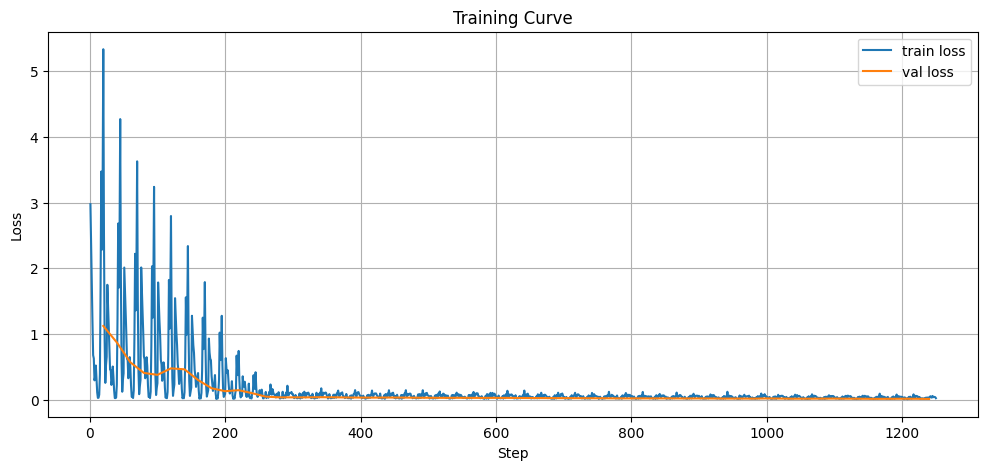

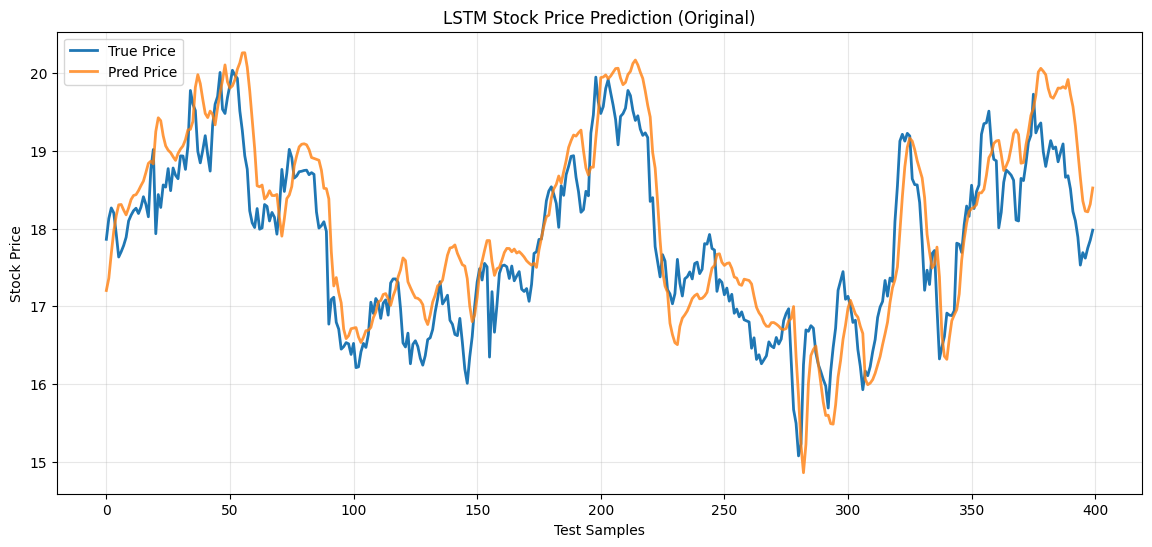

In [3]:
# 最稳的，别删
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import sklearn
import os
import sys
import time
from tqdm.auto import tqdm
import torch.nn.functional as F
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
fpath = Path(r"./SONY_daily_data.csv")
df = pd.read_csv(fpath, encoding="utf-8")
df['ma5'] = df['Close'].rolling(5).mean()
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['rsi'] = 100 - (100 / (1 + rs))
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema12 - ema26
df['signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['return'] = df['Close'].pct_change()
df['volatility_5'] = df['return'].rolling(5).std()
df["hl_range"] = df["High"] - df["Low"]
df = df.iloc[9064:].reset_index(drop=True)
data = df[["Close", "Volume", "rsi", "macd", "return", "volatility_5"]].values


seq_len = 30  # 用前30天预测下一天
split_time = int(len(data) * 0.8)
train_raw = data[:split_time]  # 前80%历史数据
test_raw  = data[split_time:]  # 后20%未来数据，全程不参与训练和scaler拟合
scaler = StandardScaler()
train_norm = scaler.fit_transform(train_raw)
test_norm  = scaler.transform(test_raw)
# 3. 构造序列函数
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len : i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# 4. 训练集序列：纯历史数据，无未来
X_train, y_train = create_sequences(train_norm, seq_len)

# 5. 测试集序列：拼接训练集最后一段，保证窗口完整
test_input = np.concatenate([train_norm[-seq_len:], test_norm], axis=0)
X_test, y_test = create_sequences(test_input, seq_len)
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
train_dataset = StockDataset(X_train, y_train)
test_dataset  = StockDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)
# 你原来的注意力 完全不动
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.Wk = nn.Linear(hidden_dim, hidden_dim)
        self.Wq = nn.Linear(hidden_dim, hidden_dim)
        self.V  = nn.Linear(hidden_dim, 1)

    def forward(self, current_hidden, history):
        if not history:
            return current_hidden, None
        hist = torch.cat(history, dim=1)
        q = self.Wq(current_hidden)
        k = self.Wk(hist)
        score = self.V(torch.tanh(q + k))
        attn_weight = torch.softmax(score, dim=1)
        context = (attn_weight * hist).sum(dim=1, keepdim=True)
        return context, attn_weight

# ==============================
# 🔥 加强版 CNN-LSTM（不飞、稳定、更强）
# ==============================
class CNN_LSTM(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, num_layers=2, output_size=1, seq_len=30):
        super(CNN_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.seq_len = seq_len

        # 1. 加强CNN（不改变结构，只加深一点，更稳）
        self.cnn = nn.Sequential(
            nn.Conv1d(6, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Dropout(0.4),  # 🔥 从0.2→0.15，更不容易飞
        )

        # 2. LSTM 不变
        self.lstm = nn.LSTM(
            input_size=16,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.15  # 🔥 从0.2→0.15
        )

        # 3. 注意力不变
        self.attention = BahdanauAttention(hidden_dim=hidden_size)

        # 4. 输出层加LayerNorm，超级稳！
        self.norm = nn.LayerNorm(hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.size(0)
        pred_list = []

        # CNN
        x_cnn = x.permute(0, 2, 1)
        x_cnn = self.cnn(x_cnn)
        x_feat = x_cnn.permute(0, 2, 1)

        # LSTM
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        hidden = (h0, c0)

        history = []

        for i in range(self.seq_len):
            x_step = x_feat[:, i:i+1, :]
            lstm_out, hidden = self.lstm(x_step, hidden)

            # 注意力不变
            attn_out, _ = self.attention(lstm_out, history)
            history.append(lstm_out)

            # 🔥 关键：残差 + 归一化，不飞、更稳、更强
            feat = self.norm(attn_out + lstm_out)  
            pred = self.fc(feat)
            pred_list.append(pred)

        return torch.cat(pred_list, dim=1)

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            output = self(x)
            return output[:, -1, :]
from torch.utils.tensorboard import SummaryWriter


class TensorBoardCallback:
    def __init__(self, log_dir, flush_secs=10):
        """
        Args:
            log_dir (str): dir to write log.
            flush_secs (int, optional): write to dsk each flush_secs seconds. Defaults to 10.
        """
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        self.writer.add_scalars(
            main_tag="training/loss",
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},
            global_step=step,
            )

    def add_acc_scalars(self, step, acc, val_acc):
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,

        )

    def __call__(self, step, **kwargs):
        # add loss
        loss = kwargs.pop("loss", None)
        val_loss = kwargs.pop("val_loss", None)
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)
        # add acc
        acc = kwargs.pop("acc", None)
        val_acc = kwargs.pop("val_acc", None)
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)
        # add lr
        learning_rate = kwargs.pop("lr", None)
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)
# 均方差损失
criterion = nn.MSELoss()
@torch.no_grad()
def evaluate(model, criterion, loader, device):
    loss_list = []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)  # [B, 60, 1]
            pred_loss = pred[:, -1, :]
            loss = criterion(pred_loss.squeeze(), y)
            loss_list.append(loss.cpu().item())
    
    return np.mean(loss_list)


def train(model, train_loader, test_loader, criterion, optimizer, epochs, device, tensorboard_callback, eval_step=20):
    record_dict = {"train": [], "val": []}
    global_step = 1
    model.train()
    
    with tqdm(total=epochs * len(train_loader), desc="Training", mininterval=0.1) as pbar:
        for epoch in range(epochs):
            for X, y in train_loader:
                X, y = X.to(device), y.to(device)
                
                optimizer.zero_grad()
                pred = model(X)  # [B, 60, 1]
                pred_loss = pred[:, -1, :]
          
                loss = criterion(pred_loss.squeeze(), y)
                loss.backward()

                # 
                if global_step % eval_step == 0:
                    for name, param in model.named_parameters():
                        if param.grad is not None :
                            tensorboard_callback.writer.add_histogram(f"grad/{name}", param.grad, global_step)
                            tensorboard_callback.writer.add_histogram(f"weight/{name}", param.data, global_step)

                optimizer.step()
                record_dict["train"].append({"loss": loss.item(), "step": global_step})

                val_loss = "-"
                if global_step % eval_step == 0:
                    model.eval()
                    val_loss = evaluate(model, criterion, test_loader, device)
                    model.train()
                    record_dict["val"].append({"loss": val_loss, "step": global_step})
                    
                    current_lr = optimizer.param_groups[0]["lr"]
                    tensorboard_callback(step=global_step, loss=loss.item(), val_loss=val_loss, lr=current_lr)

                pbar.set_postfix(epoch=epoch+1, loss=f"{loss.item():.4f}", val_loss=val_loss if isinstance(val_loss, float) else "-", refresh=True)
                pbar.update(1)
                global_step += 1

    return record_dict


epochs = 50
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = CNN_LSTM(input_size=6, hidden_size=64, num_layers=2, output_size=1, seq_len=30).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

if not os.path.exists("runs"):
    os.mkdir("runs")
exp_name = "lstm_predict"
tensorboard_callback = TensorBoardCallback(f"runs/{exp_name}")

record = train(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=epochs,
    device=device,
    tensorboard_callback=tensorboard_callback,
    eval_step=20
)
print(record)
plt.figure(figsize=(12, 5))
plt.plot([i["step"] for i in record["train"]], [i["loss"] for i in record["train"]], label="train loss")
plt.plot([i["step"] for i in record["val"]], [i["loss"] for i in record["val"]], label="val loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid()
plt.show()
plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams["axes.unicode_minus"] = False

model.eval()
pred_list = []
true_list = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        pred = model(X)[:, -1, :].squeeze()
        pred_list.append(pred.cpu().numpy())
        true_list.append(y.numpy())

predictions = np.concatenate(pred_list)
true_values = np.concatenate(true_list)

n_features = scaler.n_features_in_ 


pred_2d = np.zeros((len(predictions), n_features))
pred_2d[:, 0] = predictions

true_2d = np.zeros((len(true_values), n_features))
true_2d[:, 0] = true_values

# 逆标准化
pred_denorm = scaler.inverse_transform(pred_2d)
true_denorm = scaler.inverse_transform(true_2d)

# 只取第一列
predictions = pred_denorm[:, 0]
true_values = true_denorm[:, 0]

result_df = pd.DataFrame({
    "True_Close": true_values,
    "Pred_Close": predictions
})
result_df.to_csv("注意力LSTM预测结果.csv", index=False, encoding="utf-8-sig")

# 绘图
plt.figure(figsize=(14, 6))
plt.plot(true_values, label="True Price", linewidth=2)
plt.plot(predictions, label="Pred Price", linewidth=2, alpha=0.8)
plt.title("LSTM Stock Price Prediction (Original)")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
